In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d import Axes3D

In [2]:
a = 0.8
rh = 1 + math.sqrt(1 - a**2) # Event Horizon for a Kerr Black Hole

print("rh = ", rh)

rh =  1.5999999999999999


**Ορισμός συναρτήσεων**

In [3]:
def Δ(r,θ):
  return r**2 -2*r + a**2

def ρ2(r,θ):
  return r**2 + (a**2)*(np.cos(θ)**2)

def gtt(r,θ):
  return -(1-(2*r/ρ2(r,θ)))

def gtφ(r,θ):
  return -2*a*r*(np.sin(θ)**2)/ρ2(r,θ)

def grr(r,θ):
  return ρ2(r,θ)/Δ(r,θ)

def gθθ(r,θ):
  return ρ2(r,θ)

def gφφ(r,θ):
  return (r**2 + a**2 + ((2*r*a**2*(np.sin(θ))**2)/ρ2(r,θ)))*(np.sin(θ))**2

def A(r,θ):
  return (gtφ(r,θ))**2 - gtt(r,θ)*gφφ(r,θ)

tol=1e-12

def S(r,θ):
  value = r**2 - 2*r +a**2*np.cos(θ)**2
  return 0 if abs(value) < tol else value

**Αρχικές Συνθήκες**

In [6]:
# Αρχικές συντεταγμένες του σωματιδίου

r0 = 10
φ0 = np.pi/3
θ0 = np.pi/4

if S(r0,θ0) == 0 and a > 0 :
  print("The particle is located at the static limit")

if S(r0,θ0) == 0 and a == 0 :
  print("The particle is located at the event horizon")

if S(r0,θ0) < 0:
  print("The particle is inside the ergosphere")

if S(r0,θ0) > 0:
  print("The particle is outside of the ergosphere")

The particle is outside of the ergosphere


**Σταθερές της κίνησης**

In [12]:
E = 1.02
L = 3.4

L2 = L**2
Z = 0.02

Q_min = np.cos(θ0)**2 * (a**2*(1-E**2) + (L**2/np.sin(θ0)**2))
Q = 1.2*Q_min

# K = 5
# Q = K - (L-a*E)**2
#Q = 0

# Ταχύτητες uθ0, uφ0 και ut0
if θ0 != np.pi/2:
  uθ0 = (Q - np.cos(θ0)**2*(-a**2*E**2 + (L**2/np.sin(θ0)**2)))/gθθ(r0,θ0)
else:
  uθ0 = Q/gθθ(r0,θ0)

uφ0 = -(E*gtφ(r0,θ0) + L*gtt(r0,θ0))/A(r0,θ0)

ut0 = (E*gφφ(r0,θ0) + L*gtφ(r0,θ0))/A(r0,θ0)

print("ut0 = ", ut0)
print("uφ0 = ", uφ0)
print("uθ0 = ", uθ0)
print("Q = ", Q)

ut0 =  1.2670586187691453
uφ0 =  0.06953146755778336
uθ0 =  0.0262102711323764
Q =  13.856486400000001


In [13]:
'''
Συνθήκη για το ur0. Πρέπει το ur0 να είναι πραγματικός αριθμός, προκειμένου η
τετραταχύτητα του σωματιδίου να υπακούει στην σχέση u u = -1. Αν πετάξει error
το πρόγραμμα αυτό σημαίνει ότι δεν μπορεί να υπάρξει σωματίδιο με τις παραπάνω
αρχικές ταχύτητες.

'''
# Ορισμός της συνάρτησης h(r,θ)
def h(r,θ):
  return -(gtt(r,θ)*ut0**2 + gφφ(r,θ)*uφ0**2 + gθθ(r,θ)*uθ0**2 + 2*gtφ(r,θ)*ut0*uφ0)

if h(r0,θ0)  < 0:
  print("h(r0,θ0) = ", h(r0,θ0))
  print("ERROR")

else:
  ur0 = np.sqrt(h(r0,θ0)/grr(r0,θ0))
  print("ur0 = ", ur0)


ur0 =  0.8907515858647216


In [14]:
'''

Δουλεύμε σε πολικές συντεταγμές της μορφής (r,φ,θ). Η σειρά των δεικτών 1,2,3
που θα χρησιμοποιηθεί παρακάτω θα έχει ως εξής:
r -- 1
φ -- 2
θ -- 3

Θα ισχύει:
dr/dτ = f1(r,θ)
dφ/dτ = f2(r,θ)
dθ/dτ = f3(r,θ),

όπου τα f1,f2,f3 θα οριστούν παρακάτω ως μία ενιαία διανυσματική συνάρτηση
προκειμένου να χρησιμοποιηθεί στις επαναλήψεις της Runge Kutta.
Οι συναρτήσεις και γενικά όλο το πρόγραμμα ακολουθεί τις ονομασίες του paper
Bardeen (1972)


'''
def T(r,θ):
  return E*(r**2 + a**2) - L*a

def Vr(r,θ):
  return T(r,θ)**2 - Δ(r,θ)*((L-a*E)**2 + Q)

tol=1e-12

def Vθ(r, θ):
    value = Q - (np.cos(θ)**2)*(a**2*(1-E**2) + (L**2/np.sin(θ)**2))
    return 0 if abs(value) < tol else value

#def Vθ(r,θ):
  #return Q - (np.cos(θ)**2)*(-a**2*E**2 + (L**2/np.sin(θ)**2))


In [15]:
Vθ(r0,θ0)

np.float64(2.3094143999999996)

In [16]:

# Σταθερές σr, σθ που ρυθμίζουν την κατεύθυνση των ταχυτήτων ur και uθ

σr = -1
σθ = 1

In [17]:
# Δημιουργία διανυσματικής συνάρτησης

def f1(r,θ):
  return σr*np.sqrt(Vr(r,θ))/ρ2(r,θ)

def f2(r,θ):
  return (-(a*E - L/(np.sin(θ)**2)) + (a*T(r,θ)/Δ(r,θ)))/ρ2(r,θ)

def f3(r,θ):
  return σθ*np.sqrt(Vθ(r,θ))/ρ2(r,θ)

funcs = [f1 , f2 , f3]

In [18]:
b1 = 0   #Aρχική χρονική στιγμή του σωματιδίου
b2 = 50 #Τελική χρονική στιγμή του σωματιδίου

dt = 0.001 #Χρονικό βήμα

N = int((b2-b1)/dt) #Αριθμός βημάτων

#Λίστες
r = [0]*(N+1)
φ = [0]*(N+1)
θ = [0]*(N+1)
τ = [0]*(N+1)

#Αρχικές συνθήκες
r[0] = r0
φ[0] = φ0
θ[0] = θ0
τ[0] = b1

rstop = rh + 0.01 # Η απόσταση από το κέντρο της μαύρης τρύπας που θα σταματήσει
#                   η επανάληψη της RK4

In [19]:
# Ορισμός των k που θα χρησιμοποιήσουμε για την Runge - Kutta

k = np.zeros((4, 3))

In [20]:
c_r = 1
c_θ = 1

for j in range(N):

  if r[j] > rstop:

    if (Vr(r[j] + k[3][0],θ[j]) >= 0) and (Vθ(r[j],θ[j] + k[3][2]) >= 0):

        k[0][0] = c_r*dt*funcs[0](r[j],θ[j])
        k[0][1] = dt*funcs[1](r[j],θ[j])
        k[0][2] = c_θ*dt*funcs[2](r[j],θ[j])

        k[1][0] = c_r*dt*funcs[0](r[j] + 0.5*k[0][0], θ[j] + 0.5*k[0][2])
        k[1][1] = dt*funcs[1](r[j] + 0.5*k[0][0], θ[j] + 0.5*k[0][2])
        k[1][2] = c_θ*dt*funcs[2](r[j] + 0.5*k[0][0], θ[j] + 0.5*k[0][2])

        k[2][0] = c_r*dt*funcs[0](r[j] + 0.5*k[1][0], θ[j] + 0.5*k[1][2])
        k[2][1] = dt*funcs[1](r[j] + 0.5*k[1][0], θ[j] + 0.5*k[1][2])
        k[2][2] = c_θ*dt*funcs[2](r[j] + 0.5*k[1][0], θ[j] + 0.5*k[1][2])

        k[3][0] = c_r*dt*funcs[0](r[j] + k[2][0], θ[j] + k[2][2])
        k[3][1] = dt*funcs[1](r[j] + k[2][0], θ[j] + k[2][2])
        k[3][2] = c_θ*dt*funcs[2](r[j] + k[2][0], θ[j] + k[2][2])

        r[j+1] = r[j] + (k[0][0] + 2*k[1][0] + 2*k[2][0] + k[3][0])/6
        φ[j+1] = φ[j] + (k[0][1] + 2*k[1][1] + 2*k[2][1] + k[3][1])/6
        θ[j+1] = θ[j] + (k[0][2] + 2*k[1][2] + 2*k[2][2] + k[3][2])/6
        τ[j+1] = τ[j] + dt

    elif ((Vr(r[j] + k[3][0],θ[j]) < 0)):

        c_r *= -1

        k[0][0] = c_r*dt*funcs[0](r[j],θ[j])
        k[0][1] = dt*funcs[1](r[j],θ[j])
        k[0][2] = c_θ*dt*funcs[2](r[j],θ[j])

        k[1][0] = c_r*dt*funcs[0](r[j] + 0.5*k[0][0], θ[j] + 0.5*k[0][2])
        k[1][1] = dt*funcs[1](r[j] + 0.5*k[0][0], θ[j] + 0.5*k[0][2])
        k[1][2] = c_θ*dt*funcs[2](r[j] + 0.5*k[0][0], θ[j] + 0.5*k[0][2])

        k[2][0] = c_r*dt*funcs[0](r[j] + 0.5*k[1][0], θ[j] + 0.5*k[1][2])
        k[2][1] = dt*funcs[1](r[j] + 0.5*k[1][0], θ[j] + 0.5*k[1][2])
        k[2][2] = c_θ*dt*funcs[2](r[j] + 0.5*k[1][0], θ[j] + 0.5*k[1][2])

        k[3][0] = c_r*dt*funcs[0](r[j] + k[2][0], θ[j] + k[2][2])
        k[3][1] = dt*funcs[1](r[j] + k[2][0], θ[j] + k[2][2])
        k[3][2] = c_θ*dt*funcs[2](r[j] + k[2][0], θ[j] + k[2][2])

        r[j+1] = r[j] + (k[0][0] + 2*k[1][0] + 2*k[2][0] + k[3][0])/6
        φ[j+1] = φ[j] + (k[0][1] + 2*k[1][1] + 2*k[2][1] + k[3][1])/6
        θ[j+1] = θ[j] + (k[0][2] + 2*k[1][2] + 2*k[2][2] + k[3][2])/6
        τ[j+1] = τ[j] + dt

    elif ((Vθ(r[j],θ[j] + k[3][2]) < 0)):

        c_θ *= -1

        k[0][0] = c_r*dt*funcs[0](r[j],θ[j])
        k[0][1] = dt*funcs[1](r[j],θ[j])
        k[0][2] = c_θ*dt*funcs[2](r[j],θ[j])

        k[1][0] = c_r*dt*funcs[0](r[j] + 0.5*k[0][0], θ[j] + 0.5*k[0][2])
        k[1][1] = dt*funcs[1](r[j] + 0.5*k[0][0], θ[j] + 0.5*k[0][2])
        k[1][2] = c_θ*dt*funcs[2](r[j] + 0.5*k[0][0], θ[j] + 0.5*k[0][2])

        k[2][0] = c_r*dt*funcs[0](r[j] + 0.5*k[1][0], θ[j] + 0.5*k[1][2])
        k[2][1] = dt*funcs[1](r[j] + 0.5*k[1][0], θ[j] + 0.5*k[1][2])
        k[2][2] = c_θ*dt*funcs[2](r[j] + 0.5*k[1][0], θ[j] + 0.5*k[1][2])

        k[3][0] = c_r*dt*funcs[0](r[j] + k[2][0], θ[j] + k[2][2])
        k[3][1] = dt*funcs[1](r[j] + k[2][0], θ[j] + k[2][2])
        k[3][2] = c_θ*dt*funcs[2](r[j] + k[2][0], θ[j] + k[2][2])

        r[j+1] = r[j] + (k[0][0] + 2*k[1][0] + 2*k[2][0] + k[3][0])/6
        φ[j+1] = φ[j] + (k[0][1] + 2*k[1][1] + 2*k[2][1] + k[3][1])/6
        θ[j+1] = θ[j] + (k[0][2] + 2*k[1][2] + 2*k[2][2] + k[3][2])/6
        τ[j+1] = τ[j] + dt

  else:
    r[j+1] = r[j]
    φ[j+1] = φ[j]
    θ[j+1] = θ[j]
    τ[j+1] = τ[j] + dt







Text(0.5, 1.0, 'Διάγραμμα r = r(τ)')

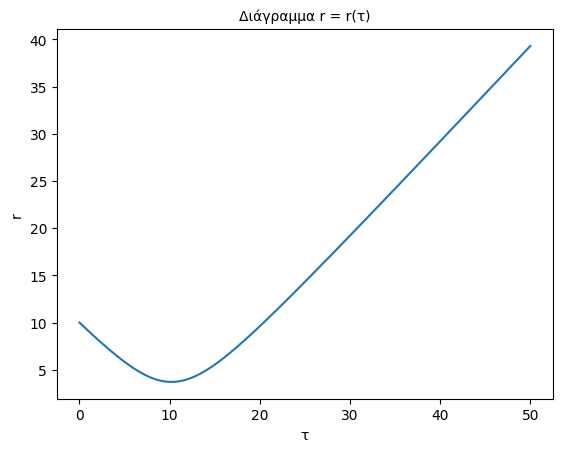

In [21]:
plt.plot(τ, r)
plt.xlabel('τ')
plt.ylabel('r')
plt.title('Διάγραμμα r = r(τ)', fontsize = 10)

In [22]:
#Λίστες
x = [0]*(N)
y = [0]*(N)
z = [0]*(N)

for i in range(N):
  x[i] = r[i]*math.cos(φ[i])*math.sin(θ[i])
  y[i] = r[i]*math.sin(φ[i])*math.sin(θ[i])
  z[i] = r[i]*math.cos(θ[i])


In [23]:
#circle1 = plt.Circle((0, 0), 2, color='black')
#ax.plot_surface(xs, ys, zs, color='black', alpha=0.6, rstride=1, cstride=1, linewidth=0)
#plt.gca().add_artist(circle1)
#plt.plot(x,y,color = 'red')
#ax.plot3D(x, y, z, color='royalblue', label='Geodesic path')
#ax.set_box_aspect([1,1,1])

#ax.set_title('Τροχιά Σωματιδιού', fontsize = 10)
#plt.axis("equal")
#plt.show()

In [24]:
# Δημιουργία σφαίρας ακτίνας rh

#fig = plt.figure()
#ax = fig.add_subplot(111, projection='3d')

u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
rs = rh                                  # Event Horizon radius

xs = rs * np.outer(np.cos(u), np.sin(v))
ys = rs * np.outer(np.sin(u), np.sin(v))
zs = rs * np.outer(np.ones(np.size(u)), np.cos(v))

Text(0.5, 0.92, 'Τροχιά Σωματιδιού')

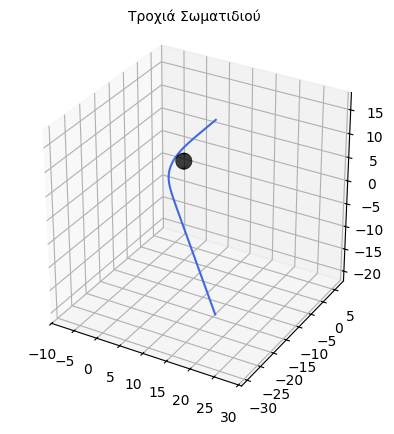

In [25]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(xs, ys, zs, color='black', alpha=0.6, rstride=1, cstride=1, linewidth=0)
ax.plot3D(x, y, z, color='royalblue', label='Geodesic path')
ax.set_box_aspect([1,1,1])
plt.axis("equal")
ax.set_title('Τροχιά Σωματιδιού', fontsize = 10)

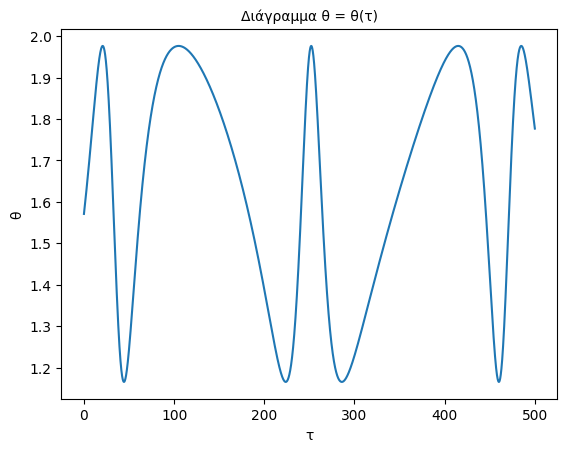

In [ ]:
plt.plot(τ,θ)
plt.title('Διάγραμμα θ = θ(τ)', fontsize = 10)
plt.xlabel('τ')
plt.ylabel('θ')
#plt.axis("equal")
plt.show()

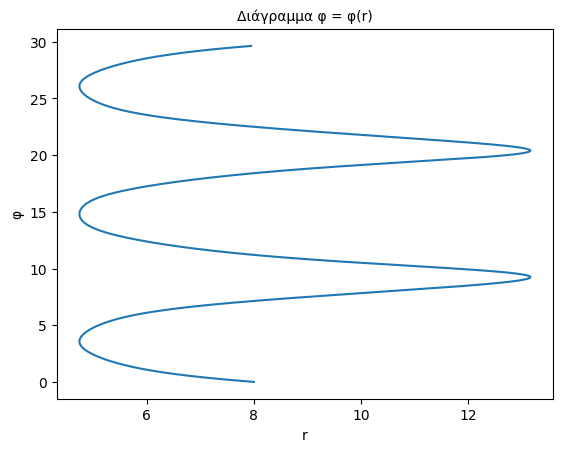

In [ ]:
plt.plot(r,φ)
plt.title('Διάγραμμα φ = φ(r)', fontsize = 10)
plt.xlabel('r')
plt.ylabel('φ')
#plt.axis("equal")
plt.show()